### Import Necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.utils import shuffle
from skimage.transform import resize
from tensorflow import keras
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

### Fetch the training data

In [4]:
damage_train = glob.glob('train_another/damage/*.jpeg')
no_damage_train = glob.glob('train_another/no_damage/*.jpeg')

In [5]:
len(damage_train)

5000

In [6]:
len(no_damage_train)

5000

### Fetch the testing data

In [8]:
damage_test = glob.glob('test_another/damage/*.jpeg')
no_damage_test = glob.glob('test_another/no_damage/*.jpeg')

In [9]:
len(damage_test)

8000

In [10]:
len(no_damage_test)

1000

### Create a list with the images and a separate one with its corresponding labels for both training and testing set

In [12]:
# Training Set
image = []
label = []

for i in damage_train:
    img = plt.imread(i)
    image.append(img)
    label.append(0)

for i in no_damage_train:
    img = plt.imread(i)
    image.append(img)
    label.append(1)

In [13]:
len(image)

10000

In [14]:
len(label)

10000

In [15]:
# Testing data
image_test = []
label_test = []

for i in damage_test:
    img = plt.imread(i)
    image_test.append(img)
    label_test.append(0)

for i in no_damage_test:
    img = plt.imread(i)
    image_test.append(img)
    label_test.append(1)

### Shuffle both images and labels

### Training Set

In [18]:
image,label = shuffle(image,label,random_state=100)

### Testing Set

In [20]:
image_test,label_test = shuffle(image_test,label_test,random_state=100)

### Plot a few images of Both Categories

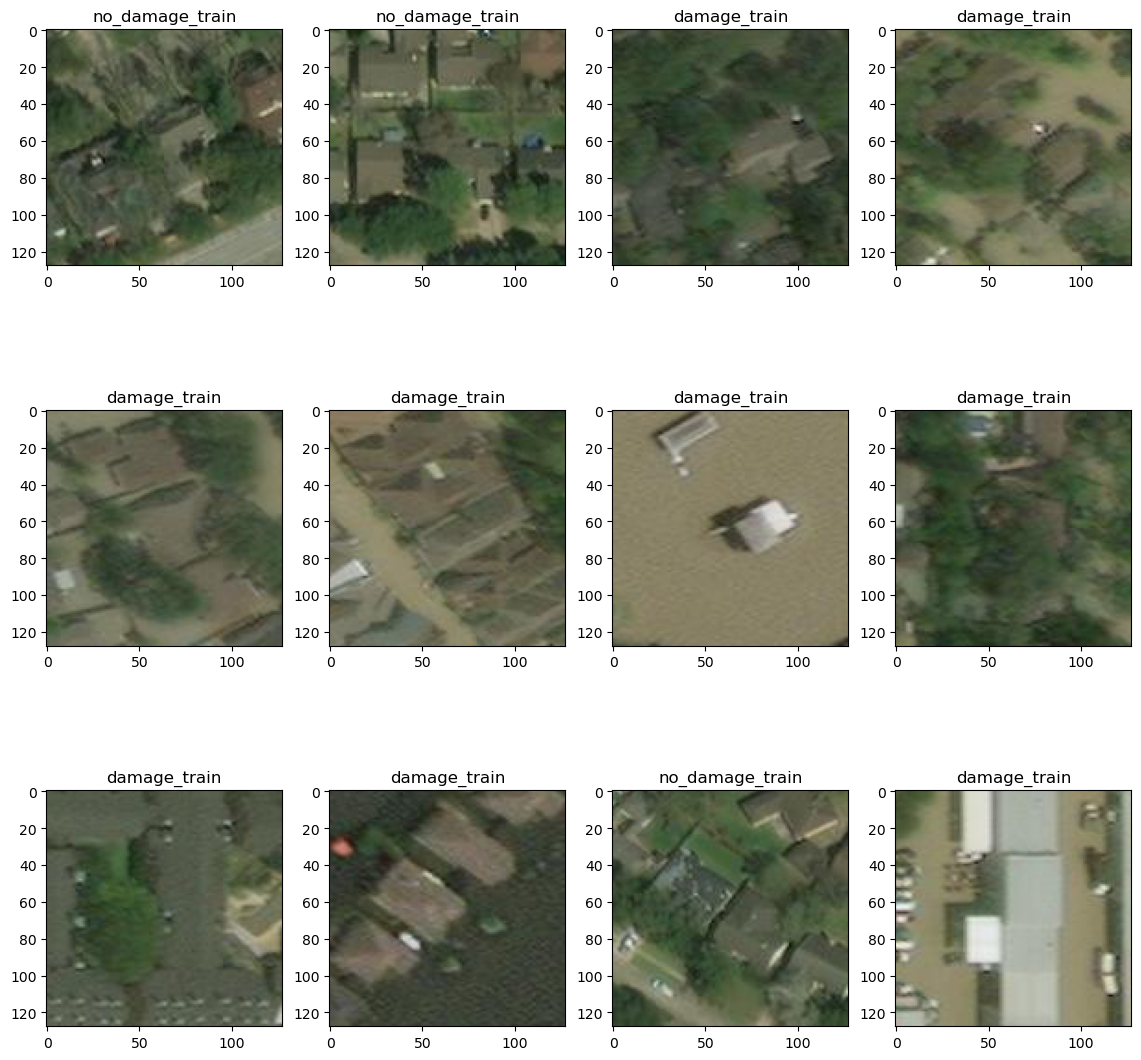

In [22]:
plt.figure(figsize=(14,14))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    if label[i] == 1:
        plt.title('no_damage_train')
    else:
        plt.title('damage_train')

### Resize the images to 64X64

In [24]:
# Training Set
X_train = []

for i in image:
    X_train.append(resize(i,(64,64,3)))

X_train = np.array(X_train)

In [25]:
#Testing Set
X_test = []

for i in image_test:
    X_test.append(resize(i,(64,64,3)))

X_test = np.array(X_test)

### Plot some of the resized images

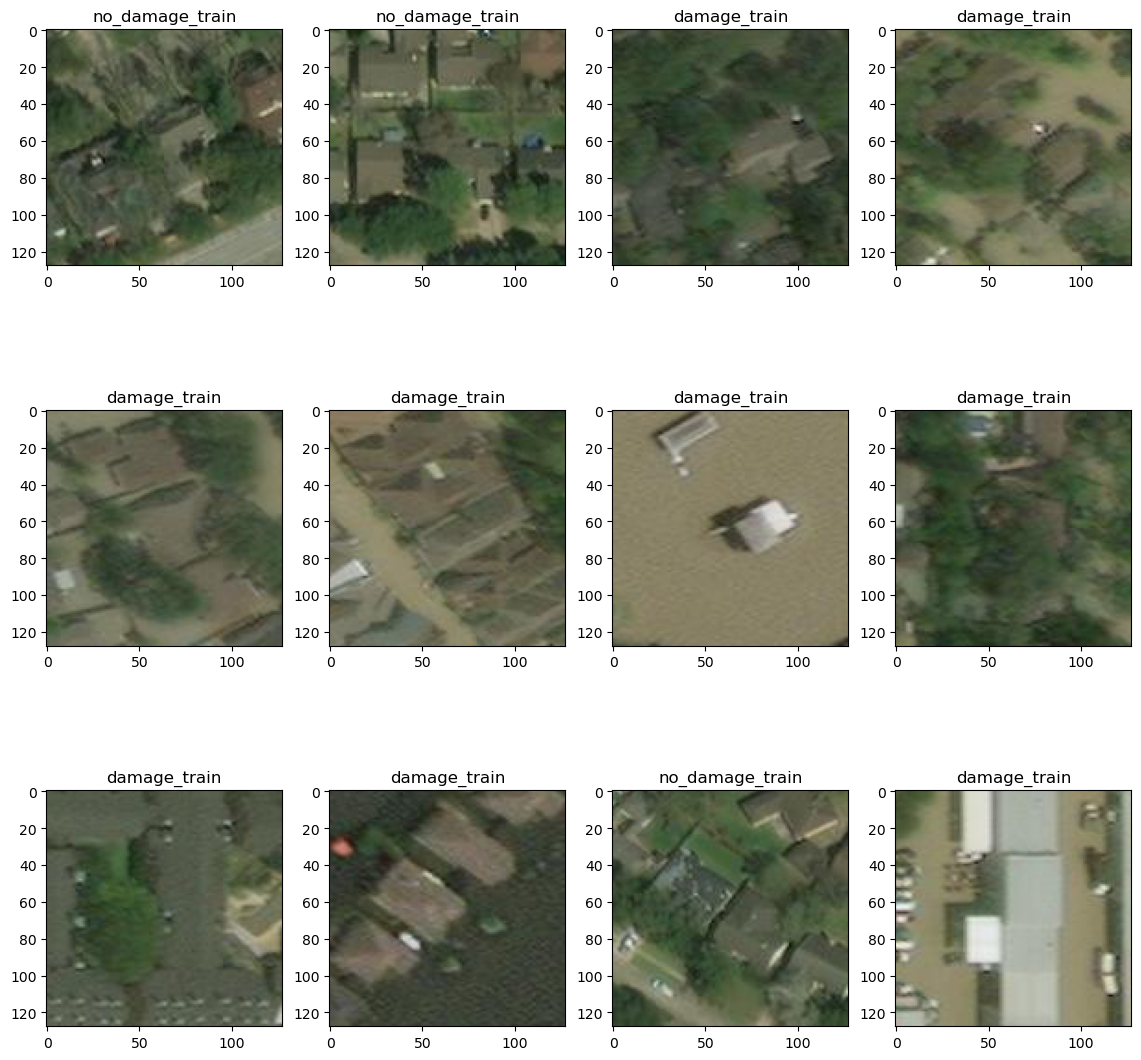

In [27]:
plt.figure(figsize=(14,14))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    if label[i] == 1:
        plt.title('no_damage_train')
    else:
        plt.title('damage_train')

In [28]:
print(type(X_train))

<class 'numpy.ndarray'>


In [29]:
print(type(label))

<class 'list'>


### Convert label and test_label to Numpy array and store it in y_train and y_test

In [31]:
y_train = np.array(label)
y_test = np.array(label_test)

In [32]:
print(type(y_train))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [33]:
X_train.shape

(10000, 64, 64, 3)

In [34]:
y_train.shape

(10000,)

### Create Keras Sequential model with 2 convolution layer, Flatten and a Hidden layer

In [36]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(64,64,3)),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Conv2D(16,(3,3),activation='relu'),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')

])

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile our model

In [38]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

### Check model summary

In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         200,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 203,601 (795.32 KB)

 Trainable params: 203,601 (795.32 KB)

 Non-trainable params: 0 (0.00 B)

### Train our model with X_train and y_train

In [42]:
model.fit(X_train,y_train,epochs=20,batch_size=32,validation_split=0.2)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.7115 - loss: 0.5650 - val_accuracy: 0.8005 - val_loss: 0.4613
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.8278 - loss: 0.4209 - val_accuracy: 0.8670 - val_loss: 0.3469
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.8559 - loss: 0.3747 - val_accuracy: 0.8815 - val_loss: 0.3133
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.8702 - loss: 0.3278 - val_accuracy: 0.8795 - val_loss: 0.3153
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8905 - loss: 0.2812 - val_accuracy: 0.8990 - val_loss: 0.2643
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9116 - loss: 0.2288 - val_accuracy: 0.9130 - val_loss: 0.2015
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9175 - loss: 0.2123 - val_accuracy: 0.9165 - val_loss: 0.1861
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9324 - loss: 0.1763 - va

### Evaluate our model

In [44]:
model.evaluate(X_train,y_train)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9763 - loss: 0.0737


[0.07370638102293015, 0.9763000011444092]

### Make Prediction with X_test

In [46]:
prediction = model.predict(X_test)

282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


In [47]:
prediction[:5]

array([[1.6035413e-04],
       [3.4403618e-04],
       [1.7464334e-02],
       [1.2909615e-03],
       [6.7668792e-05]], dtype=float32)

### Our prediction is numbers ranging from 0 to 1. We can convert values less than 0.5 to 0 and rest to 1.

In [49]:
pred = []

for i in prediction:
    if i < 0.5:
        pred.append(0)
    else:
        pred.append(1)

In [50]:
pred

[0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


### Plot X_test along with label from our prediction

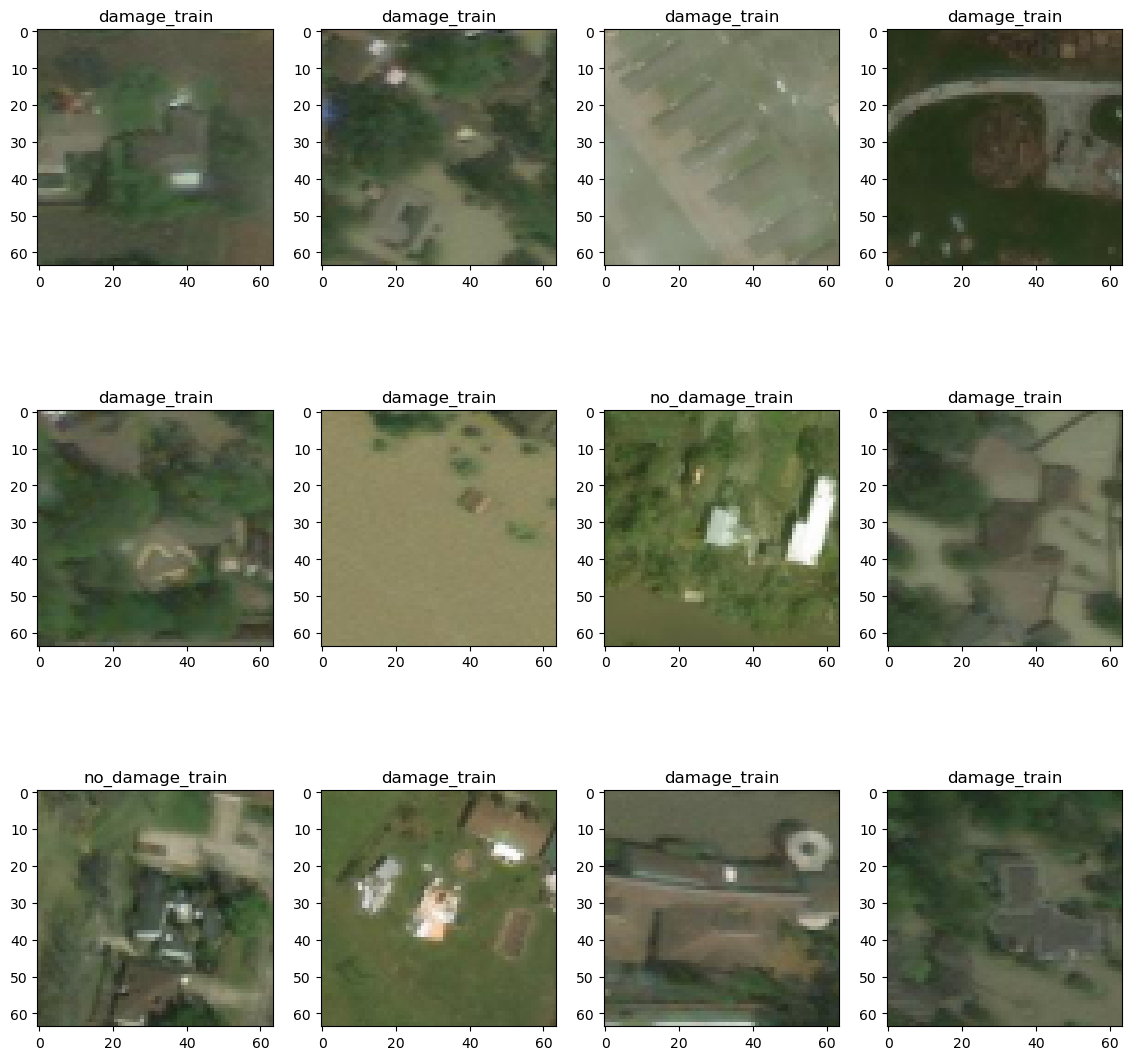

In [52]:
plt.figure(figsize=(14,14))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    if pred[i] == 1:
        plt.title('no_damage_train')
    else:
        plt.title('damage_train')

### Plot confusion matrix on a heatmap

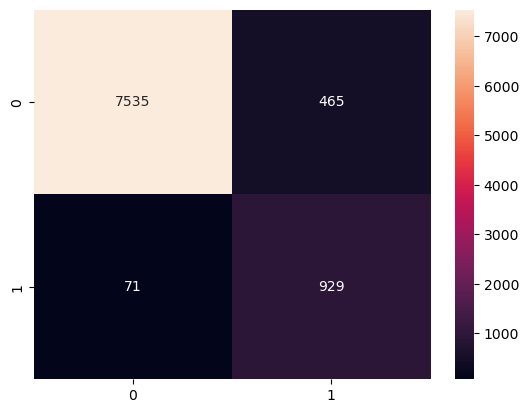

In [54]:
sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt='d')
plt.show()

### Classification Report

In [56]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      8000
           1       0.67      0.93      0.78      1000

    accuracy                           0.94      9000
   macro avg       0.83      0.94      0.87      9000
weighted avg       0.95      0.94      0.94      9000

